<a href="https://colab.research.google.com/github/aRod209/pytorch-for-deep-learning/blob/main/exercises/06_pytorch_transfer_learning_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06. PyTorch Transfer Learning Exercises

Welcome to the 06. PyTorch Transfer Learning exercise template notebook.

There are several questions in this notebook and it's your goal to answer them by writing Python and PyTorch code.

> **Note:** There may be more than one solution to each of the exercises, don't worry too much about the *exact* right answer. Try to write some code that works first and then improve it if you can.

## Resources and solutions

* These exercises/solutions are based on [section 06. PyTorch Transfer Learning](https://www.learnpytorch.io/06_pytorch_transfer_learning/) of the Learn PyTorch for Deep Learning course by Zero to Mastery.

**Solutions:**

Try to complete the code below *before* looking at these.

* See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/ueLolShyFqs).
* See an example [solutions notebook for these exercises on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/solutions/06_pytorch_transfer_learning_exercise_solutions.ipynb).

## 1. Make predictions on the entire test dataset and plot a confusion matrix for the results of our model compared to the truth labels.
* **Note:** You will need to get the dataset and the trained model/retrain the model from notebook 06 to perform predictions.
* Check out [03. PyTorch Computer Vision section 10](https://www.learnpytorch.io/03_pytorch_computer_vision/#10-making-a-confusion-matrix-for-further-prediction-evaluation) for ideas.

In [29]:
# Import required libraries/code
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from torchvision import transforms, datasets

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine

In [2]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

### Get data

In [3]:
import os
import requests
import zipfile

from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / "pizza_steak_sushi.zip")

# Setup Dirs
train_dir = image_path / "train"
test_dir = image_path / "test"

Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


### Prepare data

In [4]:
from torchvision.transforms import v2

# Create a transforms pipeline
simple_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((224, 224)),
])

In [5]:
# Create training and testing DataLoader's as well as get a list of class names
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=simple_transform, # resize, convert images to between 0 & 1 and normalize them
                                                                               batch_size=32) # set mini-batch size to 32

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7b69904c10d0>,
 ['pizza', 'steak', 'sushi'])

### Get and prepare a pretrained model

In [6]:
# Setup the model with pretrained weights and send it to the target device
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # ".DEFAULT" = best available weights
model_0 = torchvision.models.efficientnet_b0(weights=weights).to(device)
#model_0 # uncomment to output (it's very long)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 76.0MB/s]


In [7]:
# Freeze all base layers in the "features" section of the model (the feature extractor) by setting requires_grad=False
for param in model_0.features.parameters():
    param.requires_grad = False

In [8]:
# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the length of class_names (one output unit for each class)
output_shape = len(class_names)

# Recreate the classifier layer and seed it to the target device
model_0.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape, # same number of output units as our number of classes
                    bias=True)).to(device)

### Train model

In [9]:
# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=0.001)

In [10]:
# Set the random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Setup training and save the results
model_0_results = engine.train(model=model_0,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=5,
                       device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1045 | train_acc: 0.3789 | test_loss: 0.9640 | test_acc: 0.6089
Epoch: 2 | train_loss: 0.9404 | train_acc: 0.6484 | test_loss: 0.9122 | test_acc: 0.5786
Epoch: 3 | train_loss: 0.7591 | train_acc: 0.8945 | test_loss: 0.7402 | test_acc: 0.7841
Epoch: 4 | train_loss: 0.7547 | train_acc: 0.7031 | test_loss: 0.6146 | test_acc: 0.9062
Epoch: 5 | train_loss: 0.6305 | train_acc: 0.8750 | test_loss: 0.6118 | test_acc: 0.8864
[INFO] Total training time: 161.455 seconds


### Make predictions on the entire test dataset with the model

In [11]:
test_pred_labels = []

# Put model in eval mode
model_0.eval()

# Turn on inference context manager
with torch.inference_mode():
  # Loop through DataLoader batches
  for batch, (X, y) in enumerate(test_dataloader):
    # Send data to target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    test_pred_logits = model_0(X)

    # 2. Get predicted target labels
    test_pred_labels.extend(test_pred_logits.argmax(dim=1).tolist())

test_pred_labels[:5]

[0, 0, 0, 0, 0]

### Make a confusion matrix with the test preds and the truth labels

Need the following libraries to make a confusion matrix:
* torchmetrics - https://torchmetrics.readthedocs.io/en/stable/
* mlxtend - http://rasbt.github.io/mlxtend/

In [12]:
# See if torchmetrics exists, if not, install it
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
    !pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.9/981.9 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 775.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 63.7 MB/s eta 0:00:00
mlxtend version: 0.23.4


In [13]:
# Import mlxtend upgraded version
import mlxtend
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 # should be version 0.19.0 or higher

0.23.4


In [14]:
# Let's get the test data as a dataset.
test_data = datasets.ImageFolder(test_dir, transform=simple_transform)

In [15]:
from torchmetrics import ConfusionMatrix
# Setup ConfusionMatrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=torch.tensor(test_pred_labels),
                         target=torch.tensor(test_data.targets))

confmat_tensor

tensor([[23,  0,  2],
        [ 0, 16,  3],
        [ 3,  1, 27]])

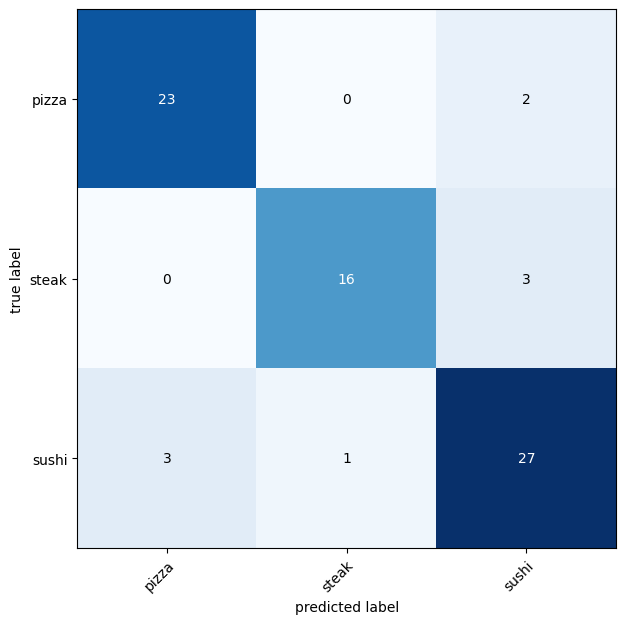

In [16]:
from mlxtend.plotting import plot_confusion_matrix

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)

## 2. Get the "most wrong" of the predictions on the test dataset and plot the 5 "most wrong" images. You can do this by:
* Predicting across all of the test dataset, storing the labels and predicted probabilities.
* Sort the predictions by *wrong prediction* and then *descending predicted probabilities*, this will give you the wrong predictions with the *highest* prediction probabilities, in other words, the "most wrong".
* Plot the top 5 "most wrong" images, why do you think the model got these wrong?

You'll want to:
* Create a DataFrame with sample, label, prediction, pred prob
* Sort DataFrame by correct (does label == prediction)
* Sort DataFrame by pred prob (descending)
* Plot the top 5 "most wrong" image predictions

We will first run predictions on the test set and store the test sample, test labels, predicted probabilities, and the predictions.

In [17]:
test_samples = []
test_labels = []
test_preds_probs = []
test_preds = []

# Put model in eval mode
model_0.eval()

# Turn on inference context manager
with torch.inference_mode():
  # Loop through DataLoader batches
  for batch, (X, y) in enumerate(test_dataloader):
    # Send data to target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    preds_logits = model_0(X)
    preds_probs = torch.softmax(preds_logits, dim=1)
    preds = preds_probs.argmax(dim=1)

    # 2. Get samples, labels, predictions, and predicted probabilities
    test_samples.extend(X.tolist())
    test_labels.extend(y.tolist())
    test_preds_probs.extend(preds_probs.tolist())
    test_preds.extend(preds.tolist())

In [18]:
type(test_samples[0])

list

In [19]:
test_labels[:5]

[0, 0, 0, 0, 0]

In [20]:
test_preds_probs[:5]

[[0.7373294234275818, 0.11966339498758316, 0.14300715923309326],
 [0.7118353247642517, 0.10287857055664062, 0.18528611958026886],
 [0.6907048225402832, 0.18597489595413208, 0.1233203336596489],
 [0.8119189739227295, 0.10590727627277374, 0.08217369765043259],
 [0.4701976478099823, 0.2710843086242676, 0.2587180435657501]]

`test_preds_probs` is a list of lists where each list (an element) are the prediction probabilities of one sample. Let us just take the highest probability from each list of samples because that is the probability for our prediction.

In [21]:
test_preds_probs = [max(preds) for preds in test_preds_probs]
test_preds_probs[:5]

[0.7373294234275818,
 0.7118353247642517,
 0.6907048225402832,
 0.8119189739227295,
 0.4701976478099823]

In [22]:
test_preds[:5]

[0, 0, 0, 0, 0]

Let's now create a `DataFrame`.

In [23]:
import pandas as pd

df = pd.DataFrame({"Sample": test_samples,
                   "Label": test_labels,
                   "Prediction": test_preds,
                  "Pred Prob": test_preds_probs})

df[:5]

,Sample,Label,Prediction,Pred Prob
0,"[[[0.0002240900503238663, 0.000258450570981949...",0,0,0.737329
1,"[[[0.24683652818202972, 0.25661852955818176, 0...",0,0,0.711835
2,"[[[0.690667450428009, 0.703683078289032, 0.697...",0,0,0.690705
3,"[[[0.8413213491439819, 0.844443678855896, 0.84...",0,0,0.811919
4,"[[[0.06760904937982559, 0.07822864502668381, 0...",0,0,0.470198


In [24]:
df['correct_pred'] = (df['Label'] == df['Prediction'])
df[:5]

,Sample,Label,Prediction,Pred Prob,correct_pred
0,"[[[0.0002240900503238663, 0.000258450570981949...",0,0,0.737329,True
1,"[[[0.24683652818202972, 0.25661852955818176, 0...",0,0,0.711835,True
2,"[[[0.690667450428009, 0.703683078289032, 0.697...",0,0,0.690705,True
3,"[[[0.8413213491439819, 0.844443678855896, 0.84...",0,0,0.811919,True
4,"[[[0.06760904937982559, 0.07822864502668381, 0...",0,0,0.470198,True


In [25]:
df[:-5]

,Sample,Label,Prediction,Pred Prob,correct_pred
0,"[[[0.0002240900503238663, 0.000258450570981949...",0,0,0.737329,True
1,"[[[0.24683652818202972, 0.25661852955818176, 0...",0,0,0.711835,True
2,"[[[0.690667450428009, 0.703683078289032, 0.697...",0,0,0.690705,True
3,"[[[0.8413213491439819, 0.844443678855896, 0.84...",0,0,0.811919,True
4,"[[[0.06760904937982559, 0.07822864502668381, 0...",0,0,0.470198,True
...,...,...,...,...,...
65,"[[[0.03174208477139473, 0.06076398864388466, 0...",2,2,0.491843,True
66,"[[[0.9954560995101929, 0.9986604452133179, 0.9...",2,2,0.486486,True
67,"[[[0.14781735837459564, 0.1471148282289505, 0....",2,2,0.590976,True
68,"[[[0.5153045058250427, 0.5199204087257385, 0.5...",2,2,0.432887,True


In [26]:
df_sorted = df.sort_values('Pred Prob').sort_values(by='correct_pred')
df_sorted[:20]

,Sample,Label,Prediction,Pred Prob,correct_pred
45,"[[[0.0013178606750443578, 0.007898417301476002...",2,0,0.492991,False
13,"[[[0.6859971284866333, 0.5940333008766174, 0.6...",0,2,0.357318,False
29,"[[[0.5181994438171387, 0.4790937304496765, 0.4...",1,2,0.369480,False
51,"[[[0.1301962286233902, 0.1300795078277588, 0.1...",2,0,0.381490,False
12,"[[[0.0965186208486557, 0.09132400900125504, 0....",0,2,0.398935,False
27,"[[[0.6723777055740356, 0.6682353019714355, 0.6...",1,2,0.516085,False
57,"[[[0.12520797550678253, 0.12707604467868805, 0...",2,0,0.446430,False
70,"[[[0.2987091541290283, 0.307299941778183, 0.32...",2,1,0.457325,False
34,"[[[0.742222249507904, 0.7622140645980835, 0.78...",1,2,0.463271,False
36,"[[[0.6412501931190491, 0.6507447361946106, 0.6...",1,1,0.706982,True


In [27]:
df_five_most_wrong = df_sorted[:5]
df_five_most_wrong

,Sample,Label,Prediction,Pred Prob,correct_pred
45,"[[[0.0013178606750443578, 0.007898417301476002...",2,0,0.492991,False
13,"[[[0.6859971284866333, 0.5940333008766174, 0.6...",0,2,0.357318,False
29,"[[[0.5181994438171387, 0.4790937304496765, 0.4...",1,2,0.369480,False
51,"[[[0.1301962286233902, 0.1300795078277588, 0.1...",2,0,0.381490,False
12,"[[[0.0965186208486557, 0.09132400900125504, 0....",0,2,0.398935,False


Let's look at the 5 most wrong predictions

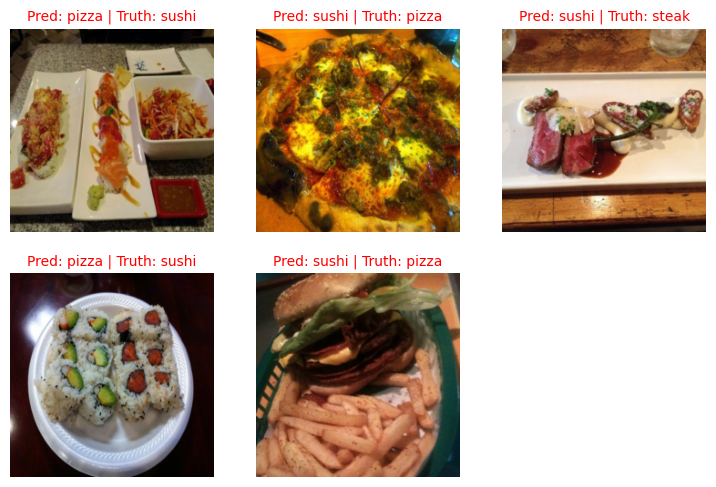

In [30]:
# Plot 5 most wrong predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3

for i, row in enumerate(df_five_most_wrong.iterrows()):
  _, df = row
  # Create subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  sample = torch.tensor(df['Sample']).permute(1,2,0) # note we will need to change shape for matplotlib (C, H, W) -> (H, W, C)
  plt.imshow(sample)

  # find the prediction (in text form, e.g. 'Pizza')
  pred_label = class_names[df['Prediction']]

  # Get the truch label (in text form)
  truth_label = class_names[df['Label']]

  # Create a title for the plot
  title_text = f'Pred: {pred_label} | Truth: {truth_label}'
  plt.title(title_text, fontsize=10, c='r')

  plt.axis(False)

## 3. Predict on your own image of pizza/steak/sushi - how does the model go? What happens if you predict on an image that isn't pizza/steak/sushi?
* Here you can get an image from a website like http://www.unsplash.com to try it out or you can upload your own.

In [42]:
from typing import List

def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str] = None,
                        transform=None,
                        device=device):
  """Makes a prediction on a target image with a trained model and plots the image and prediction."""
  # Load in the image
  target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

  # Divide the image pixel values by 255 to get them between [0, 1]
  target_image = target_image / 255

  # Transform if necessary
  if transform:
    target_image = transform(target_image)

  # Make sure the model is on the target device
  model.to(device)

  # Turn on eval/inference mode and make a prediction
  model.eval()
  with torch.inference_mode():
    # Add an extra dimension to the image (this is the batch dimension, e.g. our model will predict on batches of 1x image)
    target_image = target_image.unsqueeze(0)

    # Make a prediction on the image with an extra dimension
    target_image_pred = model(target_image.to(device)) # Make sure target image is on the right device

  # Convert logits -> prediction probabilities
  target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

  # Convert prediction probabilities -> prediction labels
  target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

  # Plot the image alongside the prediction and prediction probability
  plt.imshow(target_image.squeeze().permute(1, 2, 0)) # remove batch size and rearrange to shape HWC
  if class_names:
    title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu()}"
  else:
    title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu()}"
  plt.title(title)
  plt.axis(False)

In [37]:
# Get an image of pizza/steak/sushi
steak_image_uint8 = torchvision.io.read_image(str("data/steak.jpg"))
print(f'Custom image tensor:\n{steak_image_uint8}')
print(f'Custome image shape: {steak_image_uint8.shape}')
print(f'Custome image datatype: {steak_image_uint8.dtype}')

Custom image tensor:
tensor([[[ 96,  95,  94,  ...,  30,  36,  29],
         [ 95,  95,  94,  ...,  30,  35,  28],
         [ 94,  94,  94,  ...,  30,  34,  29],
         ...,
         [128, 128, 127,  ..., 132, 132, 132],
         [129, 128, 127,  ..., 132, 133, 132],
         [130, 129, 128,  ..., 133, 133, 132]],

        [[104, 103, 102,  ...,  38,  44,  37],
         [103, 103, 102,  ...,  38,  43,  36],
         [102, 102, 102,  ...,  38,  42,  37],
         ...,
         [145, 145, 144,  ..., 144, 144, 144],
         [146, 145, 144,  ..., 144, 145, 144],
         [147, 146, 145,  ..., 145, 145, 144]],

        [[127, 126, 123,  ...,  49,  55,  48],
         [126, 124, 123,  ...,  49,  54,  47],
         [123, 123, 123,  ...,  49,  53,  48],
         ...,
         [153, 153, 152,  ..., 142, 142, 142],
         [154, 153, 152,  ..., 142, 143, 142],
         [155, 154, 153,  ..., 143, 143, 142]]], dtype=torch.uint8)
Custome image shape: torch.Size([3, 4928, 3264])
Custome image dat

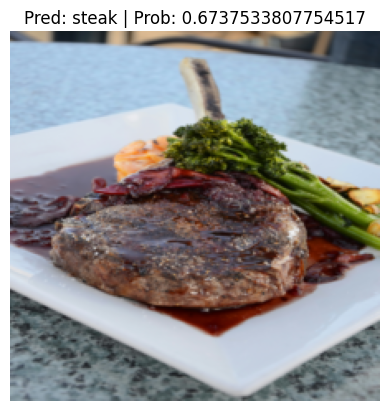

In [43]:
pred_and_plot_image(model=model_0,
                    image_path='data/steak.jpg',
                    class_names=class_names,
                    transform=simple_transform,
                    device=device)

The model predicted steak correctly! Let's now try an image of cereal and see what the model predicts.

In [32]:
# Get an image of not pizza/steak/sushi
cereal_image_uint8 = torchvision.io.read_image(str("data/cereal.jpg"))
print(f'Custom image tensor:\n{cereal_image_uint8}')
print(f'Custome image shape: {cereal_image_uint8.shape}')
print(f'Custome image datatype: {cereal_image_uint8.dtype}')

Custom image tensor:
tensor([[[197, 195, 193,  ..., 200, 201, 202],
         [195, 195, 194,  ..., 200, 201, 202],
         [193, 194, 195,  ..., 200, 201, 202],
         ...,
         [232, 232, 232,  ..., 211, 211, 211],
         [232, 232, 232,  ..., 211, 211, 211],
         [231, 231, 232,  ..., 211, 211, 211]],

        [[201, 199, 197,  ..., 204, 205, 206],
         [199, 199, 198,  ..., 204, 205, 206],
         [197, 198, 199,  ..., 204, 205, 206],
         ...,
         [233, 233, 233,  ..., 211, 211, 211],
         [233, 233, 233,  ..., 211, 211, 211],
         [232, 232, 233,  ..., 211, 211, 211]],

        [[212, 210, 208,  ..., 216, 217, 218],
         [210, 210, 209,  ..., 216, 217, 218],
         [208, 209, 210,  ..., 216, 217, 218],
         ...,
         [237, 237, 237,  ..., 221, 221, 221],
         [237, 237, 237,  ..., 221, 221, 221],
         [236, 236, 237,  ..., 221, 221, 221]]], dtype=torch.uint8)
Custome image shape: torch.Size([3, 4160, 6240])
Custome image dat

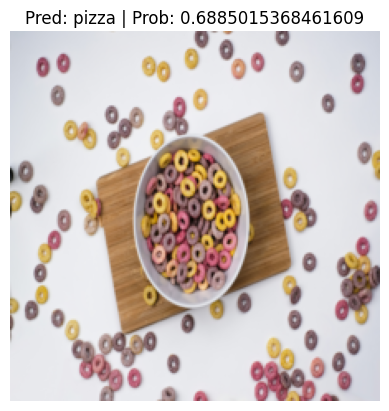

In [44]:
pred_and_plot_image(model=model_0,
                    image_path='data/cereal.jpg',
                    class_names=class_names,
                    transform=simple_transform,
                    device=device)

I suspect the model predicted pizza due to the roundness of the cereal bowl.

## 4. Train the model from section 4  in notebook 06 part 3 for longer (10 epochs should do), what happens to the performance?

* See the model in notebook 06 part 3 for reference: https://www.learnpytorch.io/06_pytorch_transfer_learning/#3-getting-a-pretrained-model

In [45]:
# Recreate a new model
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model_1 = torchvision.models.efficientnet_b0(weights=weights).to(device)

In [46]:
for param in model_1.features.parameters():
  param.requires_grad = False

In [50]:
model_1.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape,
                    bias=True)).to(device)

In [51]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters(), lr=0.001)

In [52]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as timer
start_time = timer()

model_1_results = engine.train(model=model_1,
                               train_dataloader=train_dataloader,
                               test_dataloader=test_dataloader,
                               optimizer=optimizer,
                               loss_fn=loss_fn,
                               epochs=10,
                               device=device)

end_time = timer()
print(f'[INFO] Total training time: {end_time-start_time:.3f} seconds')

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0764 | train_acc: 0.4141 | test_loss: 0.9865 | test_acc: 0.5691
Epoch: 2 | train_loss: 0.9036 | train_acc: 0.6719 | test_loss: 0.9029 | test_acc: 0.5900
Epoch: 3 | train_loss: 0.7613 | train_acc: 0.8711 | test_loss: 0.7117 | test_acc: 0.8343
Epoch: 4 | train_loss: 0.7416 | train_acc: 0.7148 | test_loss: 0.6120 | test_acc: 0.8447
Epoch: 5 | train_loss: 0.6077 | train_acc: 0.8828 | test_loss: 0.6217 | test_acc: 0.9280
Epoch: 6 | train_loss: 0.5858 | train_acc: 0.8008 | test_loss: 0.5676 | test_acc: 0.9072
Epoch: 7 | train_loss: 0.5712 | train_acc: 0.8047 | test_loss: 0.5826 | test_acc: 0.8968
Epoch: 8 | train_loss: 0.4919 | train_acc: 0.8008 | test_loss: 0.5006 | test_acc: 0.8864
Epoch: 9 | train_loss: 0.4602 | train_acc: 0.9219 | test_loss: 0.5148 | test_acc: 0.9072
Epoch: 10 | train_loss: 0.5047 | train_acc: 0.7969 | test_loss: 0.5455 | test_acc: 0.9176
[INFO] Total training time: 323.789 seconds


We see the train accuracy generally improved with each epoch excpet the last.

The test accuracy improved.

Overall, the performance was better with 10 epochs versus 5 epochs.

## 5. Train the model from section 4 above with more data, say 20% of the images from Food101 of Pizza, Steak and Sushi images.
* You can find the [20% Pizza, Steak, Sushi dataset](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip) on the course GitHub. It was created with the notebook [`extras/04_custom_data_creation.ipynb`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb).


### Get 20% data

In [53]:
import os
import requests
import zipfile

from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi_20_percent"
image_data_zip_path = "pizza_steak_sushi_20_percent.zip"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / image_data_zip_path, "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / image_data_zip_path, "r") as zip_ref:
        print("Unzipping pizza, steak, sushi 20% data...")
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / image_data_zip_path)

# Setup Dirs
train_dir_20_percent = image_path / "train"
test_dir_20_percent = image_path / "test"

train_dir_20_percent, test_dir_20_percent

Did not find data/pizza_steak_sushi_20_percent directory, creating one...
Unzipping pizza, steak, sushi 20% data...


(PosixPath('data/pizza_steak_sushi_20_percent/train'),
 PosixPath('data/pizza_steak_sushi_20_percent/test'))

### Create DataLoaders

In [54]:
# Create a transforms pipeline
simple_transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((224, 224)),
])

In [55]:
# Create training and testing DataLoader's as well as get a list of class names
train_dataloader_20_percent, test_dataloader_20_percent, class_names = data_setup.create_dataloaders(train_dir=train_dir_20_percent,
                                                                                                     test_dir=test_dir_20_percent,
                                                                                                     transform=simple_transform, # resize, convert images to between 0 & 1 and normalize them
                                                                                                     batch_size=32) # set mini-batch size to 32

train_dataloader_20_percent, test_dataloader_20_percent, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7b6a84b79150>,
 ['pizza', 'steak', 'sushi'])

### Get a pretrained model

In [56]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model_2 = torchvision.models.efficientnet_b0(weights=weights).to(device)

In [57]:
for param in model_2.parameters():
  param.requires_grad = False

In [58]:
model_2.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape,
                    bias=True)).to(device)

In [59]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_2.parameters(), lr=0.001)

### Train a model with 20% of the data

In [60]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as timer
start_time = timer()

model_2_results = engine.train(model=model_2,
                               train_dataloader=train_dataloader_20_percent,
                               test_dataloader=test_dataloader_20_percent,
                               optimizer=optimizer,
                               loss_fn=loss_fn,
                               epochs=5,
                               device=device)

end_time = timer()
print(f'[INFO] Total training time: {end_time-start_time:.3f} seconds')

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9470 | train_acc: 0.5958 | test_loss: 0.8067 | test_acc: 0.8023
Epoch: 2 | train_loss: 0.6930 | train_acc: 0.8333 | test_loss: 0.5823 | test_acc: 0.8824
Epoch: 3 | train_loss: 0.5515 | train_acc: 0.8479 | test_loss: 0.4476 | test_acc: 0.9375
Epoch: 4 | train_loss: 0.4610 | train_acc: 0.8979 | test_loss: 0.3954 | test_acc: 0.9375
Epoch: 5 | train_loss: 0.4538 | train_acc: 0.8667 | test_loss: 0.3609 | test_acc: 0.9284
[INFO] Total training time: 319.924 seconds


With just 5 epochs, this model had taken the logest to train, but it has the best training and testing accuracy.

## 6. Try a different model from [`torchvision.models`](https://pytorch.org/vision/stable/models.html) on the Pizza, Steak, Sushi data, how does this model perform?
* You'll have to change the size of the classifier layer to suit our problem.
* You may want to try an EfficientNet with a higher number than our B0, perhaps `torchvision.models.efficientnet_b2()`?
  * **Note:** Depending on the model you use you will have to prepare/transform the data in a certain way.

In [66]:
weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
model_3 = torchvision.models.efficientnet_b2(weights=weights).to(device)

In [67]:
model_3

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [62]:
for param in model_3.features.parameters():
  param.requires_grad = False

In [68]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model_3.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.3, inplace=True),
    torch.nn.Linear(in_features=1408,
                    out_features=output_shape,
                    bias=True)).to(device)

In [69]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_3.parameters(), lr=0.001)

In [70]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as timer
start_time = timer()

model_3_results = engine.train(model=model_3,
                               train_dataloader=train_dataloader,
                               test_dataloader=test_dataloader,
                               optimizer=optimizer,
                               loss_fn=loss_fn,
                               epochs=5,
                               device=device)

end_time = timer()
print(f'[INFO] Total training time: {end_time-start_time:.3f} seconds')

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.7801 | train_acc: 0.6172 | test_loss: 0.3804 | test_acc: 0.8769
Epoch: 2 | train_loss: 0.3382 | train_acc: 0.8320 | test_loss: 0.3218 | test_acc: 0.9176
Epoch: 3 | train_loss: 0.0890 | train_acc: 0.9961 | test_loss: 0.2579 | test_acc: 0.9167
Epoch: 4 | train_loss: 0.2826 | train_acc: 0.8711 | test_loss: 0.3984 | test_acc: 0.8977
Epoch: 5 | train_loss: 0.4948 | train_acc: 0.8477 | test_loss: 0.4034 | test_acc: 0.8665
[INFO] Total training time: 475.985 seconds


`torchvision.models.efficientnet_b2()` actually performed the worse out of all the models we have tried so far. Keep in mind, we only used 5 epochs on the original/smaller Food101 dataset. Perhaps, if we trained for 10 epochs on the larger (20 percent) dataset it would perform better...